<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Entangle010.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

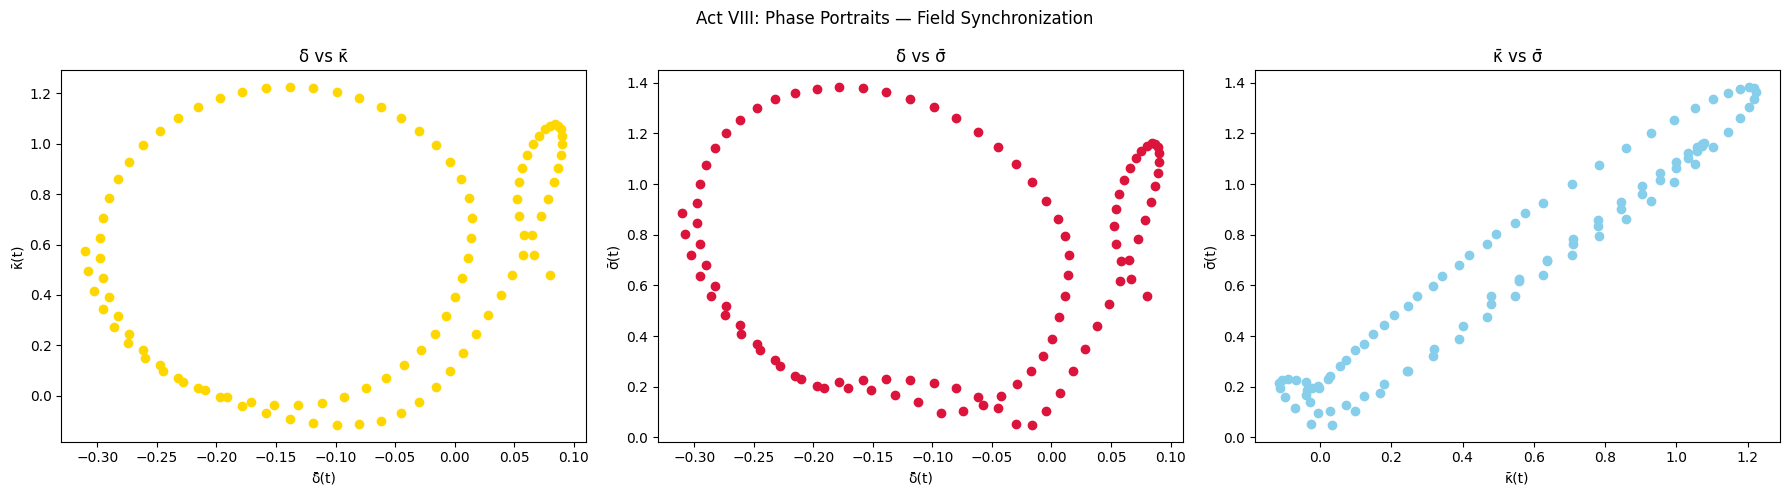

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# -------------------------------
# Step 1: Build Network
# -------------------------------
def build_boundary_bulk_network(boundary_size=8, bulk_size=32):
    G = nx.Graph()
    boundary_nodes = [f"B{i}" for i in range(boundary_size)]
    bulk_nodes = [f"U{i}" for i in range(bulk_size)]

    G.add_nodes_from(boundary_nodes, region='boundary')
    G.add_nodes_from(bulk_nodes, region='bulk')

    for b in boundary_nodes:
        connections = np.random.choice(bulk_nodes, size=4, replace=False)
        for u in connections:
            G.add_edge(b, u)

    for i in range(bulk_size):
        for j in range(i + 1, bulk_size):
            if np.random.rand() < 0.1:
                G.add_edge(f"U{i}", f"U{j}")

    return G

# -------------------------------
# Step 2: Initialize δ and κ
# -------------------------------
def initialize_weights(G, δ_init=0.5, κ_init=0.5):
    for node in G.nodes:
        region = G.nodes[node]['region']
        G.nodes[node]['delta'] = δ_init if region == 'boundary' else 0.0
        G.nodes[node]['kappa'] = κ_init if region == 'bulk' else 0.0

# -------------------------------
# Step 3: Recursive Update
# -------------------------------
def update_weights(G, t, δ_base=1.0, κ_base=1.0, α=0.9, β=0.9, γ=0.1):
    δ_t = δ_base * np.sin(2 * np.pi * t / 50)
    κ_t = κ_base * np.cos(2 * np.pi * t / 50)
    curvature = compute_curvature(G)

    for node in G.nodes:
        region = G.nodes[node]['region']
        prev_δ = G.nodes[node]['delta']
        prev_κ = G.nodes[node]['kappa']
        σ = curvature[node]

        if region == 'boundary':
            G.nodes[node]['delta'] = α * prev_δ + (1 - α) * δ_t - γ * σ
            G.nodes[node]['kappa'] = 0.0
        else:
            G.nodes[node]['kappa'] = β * prev_κ + (1 - β) * κ_t + γ * σ
            G.nodes[node]['delta'] = 0.0

# -------------------------------
# Step 4: Curvature
# -------------------------------
def compute_curvature(G):
    return {node: np.abs(G.nodes[node]['delta'] - G.nodes[node]['kappa']) for node in G.nodes}

# -------------------------------
# Step 5: Run Simulation
# -------------------------------
def run_phase_locking_simulation(frames=100):
    G = build_boundary_bulk_network()
    initialize_weights(G)

    δ_means = []
    κ_means = []
    σ_means = []

    for t in range(frames):
        update_weights(G, t)
        δ_vals = [G.nodes[n]['delta'] for n in G.nodes]
        κ_vals = [G.nodes[n]['kappa'] for n in G.nodes]
        σ_vals = list(compute_curvature(G).values())

        δ_means.append(np.mean(δ_vals))
        κ_means.append(np.mean(κ_vals))
        σ_means.append(np.mean(σ_vals))

    return δ_means, κ_means, σ_means

# -------------------------------
# Step 6: Plot Phase Portraits
# -------------------------------
δ_means, κ_means, σ_means = run_phase_locking_simulation()

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].scatter(δ_means, κ_means, color='gold')
axs[0].set_xlabel('δ̄(t)')
axs[0].set_ylabel('κ̄(t)')
axs[0].set_title('δ̄ vs κ̄')

axs[1].scatter(δ_means, σ_means, color='crimson')
axs[1].set_xlabel('δ̄(t)')
axs[1].set_ylabel('σ̄(t)')
axs[1].set_title('δ̄ vs σ̄')

axs[2].scatter(κ_means, σ_means, color='skyblue')
axs[2].set_xlabel('κ̄(t)')
axs[2].set_ylabel('σ̄(t)')
axs[2].set_title('κ̄ vs σ̄')

plt.suptitle("Act VIII: Phase Portraits — Field Synchronization")
plt.tight_layout()
plt.show()
